In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta

# Loading the data
df = pd.read_csv('/content/drive/MyDrive/steam_reviews.csv')

print("Shape:", df.shape)
df.head()

Shape: (14617, 8)


,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
0,2018-11-24,0,0,40,False,Recommended,10/10 would murder kids again,Rust
1,2016-06-28,0,0,20,False,Recommended,OH YEAH,Euro Truck Simulator 2
2,2016-01-09,0,0,292,True,Recommended,is good gam,Rust
3,2018-07-08,0,0,401,False,Recommended,Spooky.,Dead by Daylight
4,2018-12-29,1,1,125,False,Not Recommended,Tries to play for an hour with my bros.Had to ...,Grand Theft Auto V


In [5]:
# Checking descriptions of the columns and statistical information
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14617 entries, 0 to 14616
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   date_posted             14617 non-null  object
 1   funny                   14617 non-null  int64 
 2   helpful                 14617 non-null  int64 
 3   hour_played             14617 non-null  int64 
 4   is_early_access_review  14617 non-null  bool  
 5   recommendation          14617 non-null  object
 6   review                  14610 non-null  object
 7   title                   14617 non-null  object
dtypes: bool(1), int64(3), object(4)
memory usage: 813.8+ KB


,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title
count,14617,14617.000000,14617.000000,14617.000000,14617,14617,14610,14617
unique,1776,NaN,NaN,NaN,2,2,14176,23
top,2018-11-22,NaN,NaN,NaN,False,Recommended,good,PLAYERUNKNOWN'S BATTLEGROUNDS
freq,216,NaN,NaN,NaN,10384,10394,11,2539
mean,NaN,1.113019,3.715537,296.143395,NaN,NaN,NaN,NaN
std,NaN,45.535473,58.740454,510.080218,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,0.000000,0.000000,33.000000,NaN,NaN,NaN,NaN
50%,NaN,0.000000,0.000000,122.000000,NaN,NaN,NaN,NaN
75%,NaN,0.000000,0.000000,340.000000,NaN,NaN,NaN,NaN


In [6]:
# Checking for any missing values
df.isnull().sum()

,0
date_posted,0
funny,0
helpful,0
hour_played,0
is_early_access_review,0
recommendation,0
review,7
title,0


In [8]:
# Since there are 7 missing values onlly in the review column, drop the rows
df = df.dropna(subset=['review'])

In [9]:
df.isnull().sum()

,0
date_posted,0
funny,0
helpful,0
hour_played,0
is_early_access_review,0
recommendation,0
review,0
title,0


# Cleaning The Data & Converting Columns to Appropriate Types




In [11]:
# Converting date_posted to datetime
df['date_posted'] = pd.to_datetime(df['date_posted'])

# Converting recommendation to binary (1 = Recommended, 0 - Not Recommended)
df['is_recommended'] = (df['recommendation'] == 'Recommended').astype(int)

# Checking for wrong hour_played (for example negative value)
df = df[df['hour_played'] >= 0]

# Removing duplicates
df = df.drop_duplicates()

In [12]:
# Checking descriptions of the columns and statistical information
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
Index: 14610 entries, 0 to 14616
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date_posted             14610 non-null  datetime64[ns]
 1   funny                   14610 non-null  int64         
 2   helpful                 14610 non-null  int64         
 3   hour_played             14610 non-null  int64         
 4   is_early_access_review  14610 non-null  bool          
 5   recommendation          14610 non-null  object        
 6   review                  14610 non-null  object        
 7   title                   14610 non-null  object        
 8   is_recommended          14610 non-null  int64         
dtypes: bool(1), datetime64[ns](1), int64(4), object(3)
memory usage: 1.0+ MB


,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title,is_recommended
count,14610,14610.000000,14610.000000,14610.000000,14610,14610,14610,14610,14610.000000
unique,NaN,NaN,NaN,NaN,2,2,14176,23,NaN
top,NaN,NaN,NaN,NaN,False,Recommended,good,PLAYERUNKNOWN'S BATTLEGROUNDS,NaN
freq,NaN,NaN,NaN,NaN,10379,10390,11,2538,NaN
mean,2017-06-11 02:23:06.776180736,1.113142,3.716769,296.132991,NaN,NaN,NaN,NaN,0.711157
min,2010-12-20 00:00:00,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
25%,2016-10-30 00:00:00,0.000000,0.000000,33.250000,NaN,NaN,NaN,NaN,0.000000
50%,2017-07-24 00:00:00,0.000000,0.000000,122.000000,NaN,NaN,NaN,NaN,1.000000
75%,2018-06-25 00:00:00,0.000000,0.000000,340.000000,NaN,NaN,NaN,NaN,1.000000
max,2019-02-16 00:00:00,5274.000000,2464.000000,9567.000000,NaN,NaN,NaN,NaN,1.000000


# Descriptive stats per game

In [13]:
# Group by game title
game_stats = df.groupby('title').agg(
    n_reviews = ('review', 'count'),
    rec_rate = ('is_recommended', 'mean'),
    median_hours = ('hour_played', 'median'),
    mean_hours = ('hour_played', 'mean'),
    p95_hours = ('hour_played', lambda x: x.quantile(0.95)),
    n_early_access_reviews = ('is_early_access_review', 'sum'),
    mean_helpful = ('helpful', 'mean'),
    mean_funny = ('funny', 'mean')
).round(2)

# add date range for each game
date_range = df.groupby('title')['date_posted'].agg(['min', 'max'])
game_stats = game_stats.join(date_range)
game_stats['lifetime_days'] = (game_stats['max'] - game_stats['min']).dt.days

# Sort by no. of reviews (indicates popularity)
game_stats.sort_values('n_reviews', ascending=False)

,n_reviews,rec_rate,median_hours,mean_hours,p95_hours,n_early_access_reviews,mean_helpful,mean_funny,min,max,lifetime_days
title,,,,,,,,,,,
PLAYERUNKNOWN'S BATTLEGROUNDS,2538,0.68,234.0,358.75,1182.05,1282,0.24,0.14,2017-03-23,2019-02-13,692
Rust,2290,0.66,171.0,494.77,2090.30,1807,0.24,0.24,2013-12-11,2019-02-10,1887
Grand Theft Auto V,2173,0.63,182.0,289.06,930.80,0,0.50,0.31,2015-04-13,2019-02-16,1405
Rocket League®,1772,0.61,164.5,398.66,1446.45,0,0.28,0.24,2015-07-07,2019-02-13,1317
Dead by Daylight,1034,0.63,97.0,250.34,1059.20,0,0.19,0.13,2016-06-14,2019-02-09,970
The Elder Scrolls V: Skyrim Special Edition,976,0.64,46.5,99.85,315.50,0,6.48,1.05,2016-10-27,2019-02-02,828
MONSTER HUNTER: WORLD,774,0.60,107.0,153.67,453.05,0,0.61,0.32,2018-08-09,2019-02-16,191
ASTRONEER,576,0.86,28.0,52.57,161.25,531,9.22,0.90,2016-12-15,2019-02-13,790
RESIDENT EVIL 2 / BIOHAZARD RE:2,496,0.99,21.0,26.85,64.00,0,11.43,0.42,2019-01-24,2019-02-16,23


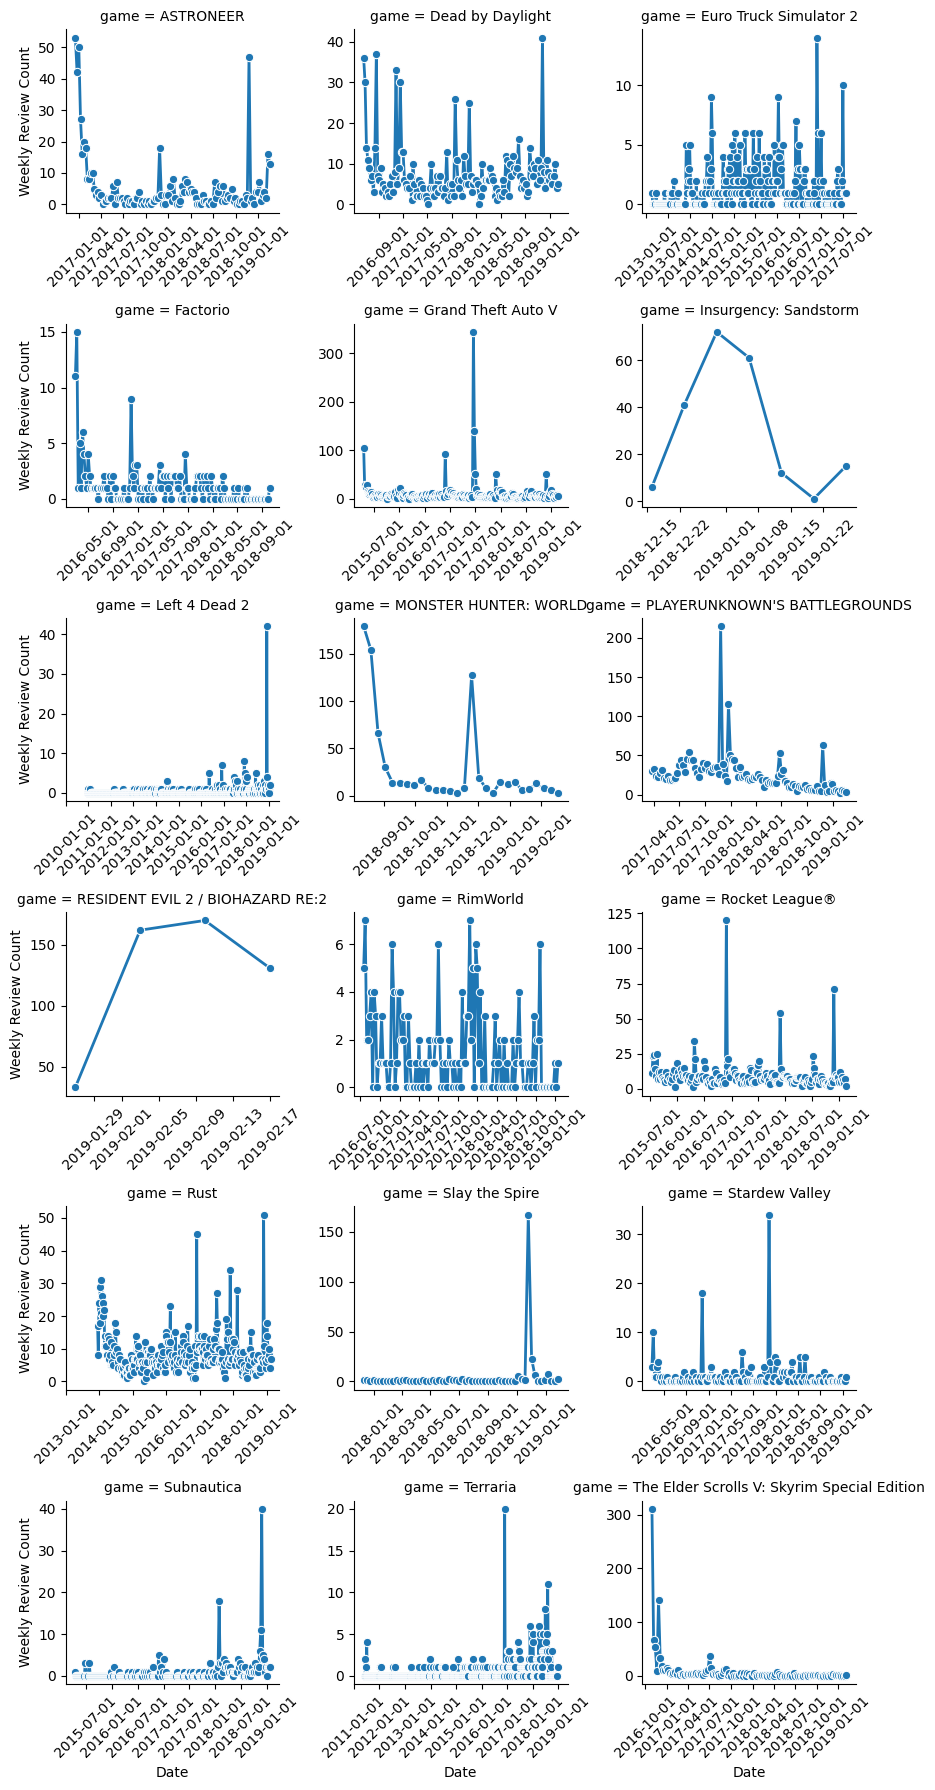

In [31]:
# Create a weekly snapshot for each game
def get_weekly_agg(game_df):
    game_df = game_df.set_index('date_posted')
    weekly = game_df.resample('W').agg(
        n_reviews = ('is_recommended', 'count'),
        rec_rate = ('is_recommended', 'mean'),
        median_hours = ('hour_played', 'median')
    )
    weekly['game'] = game_df['title'].iloc[0]
    return weekly.reset_index()

weekly_data = []
for title, group in df.groupby('title'):
    if len(group) > 10:
        weekly_data.append(get_weekly_agg(group))

weekly_df = pd.concat(weekly_data, ignore_index=True)

# Plot review volume over time
g = sns.FacetGrid(weekly_df, col='game', col_wrap=3, sharey=False, sharex=False)
g.map(sns.lineplot, 'date_posted', 'n_reviews', marker='o', linewidth=2)
g.set_axis_labels('Date', 'Weekly Review Count')
g.set_xticklabels(rotation=45)
plt.tight_layout()
plt.show()

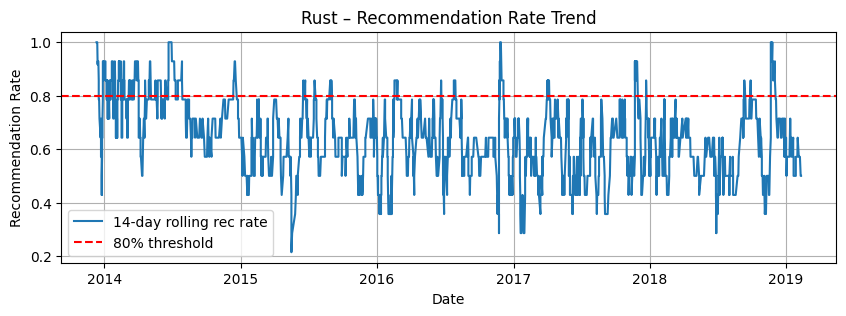

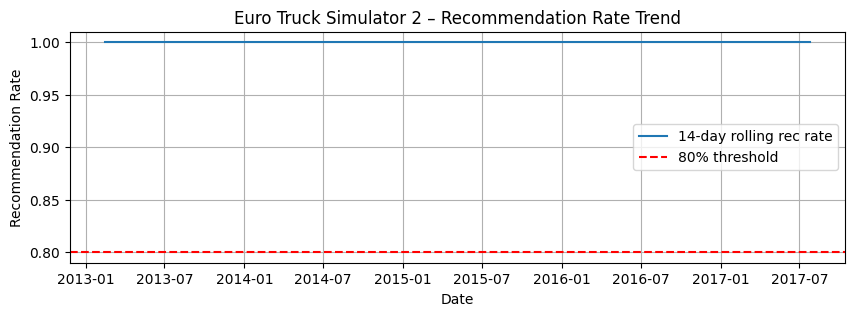

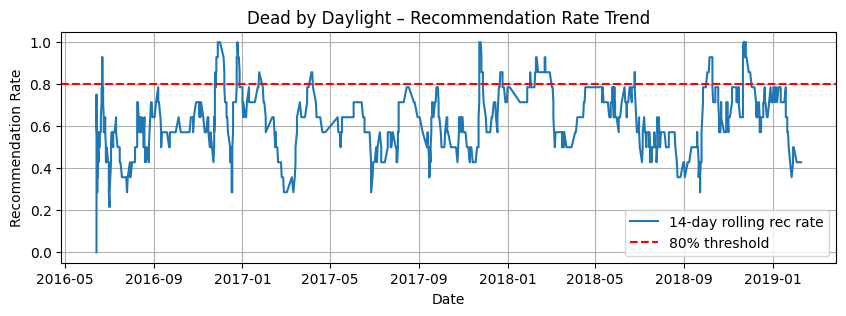

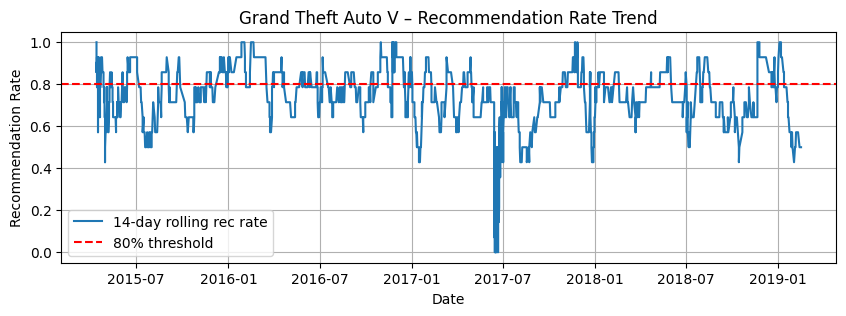

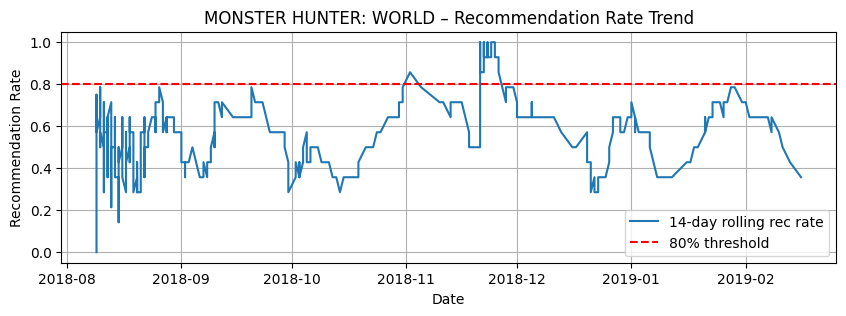

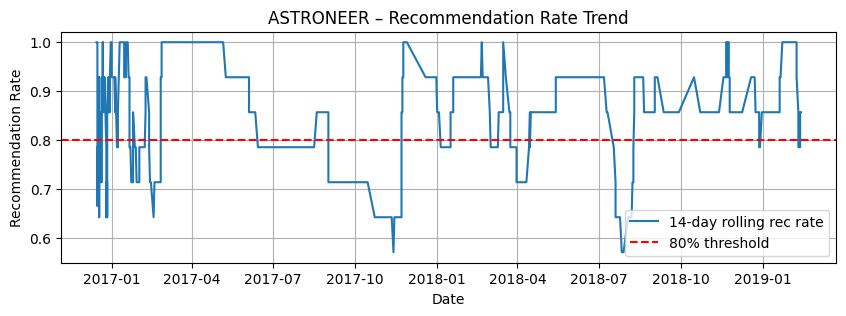

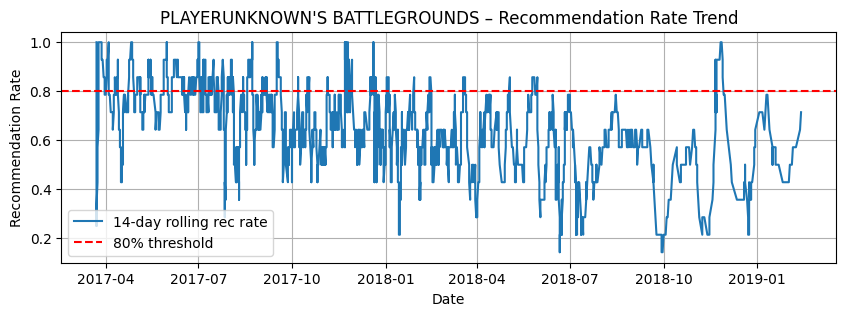

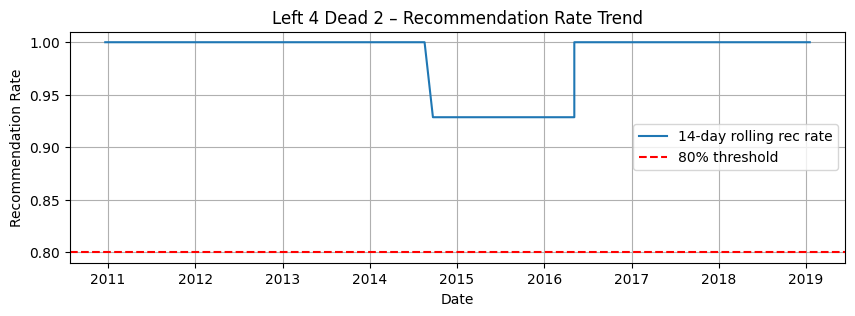

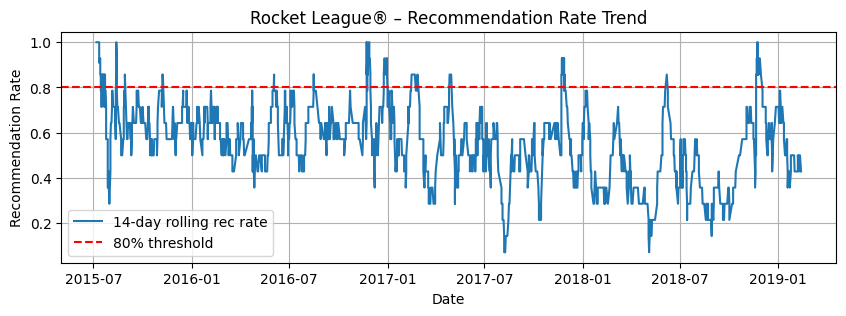

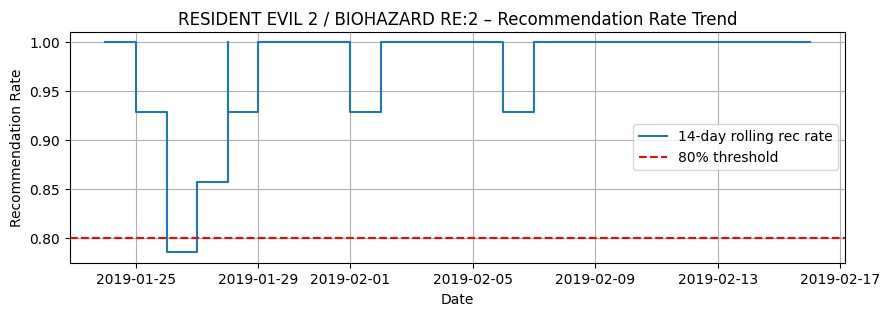

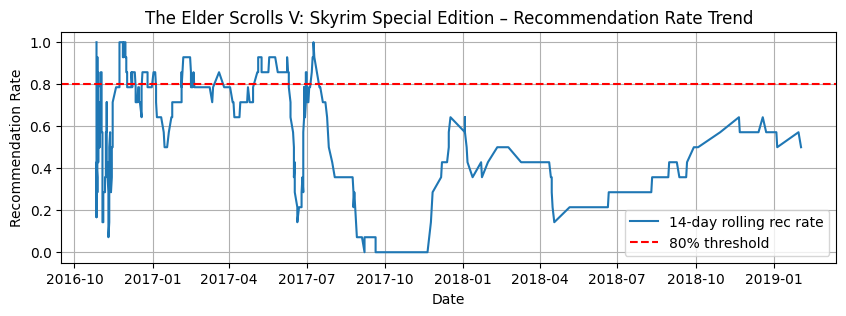

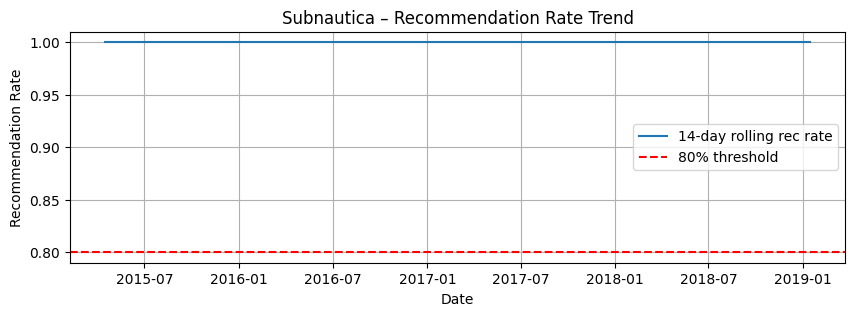

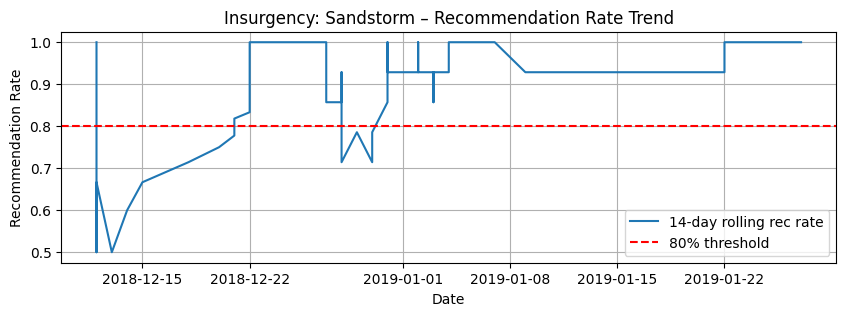

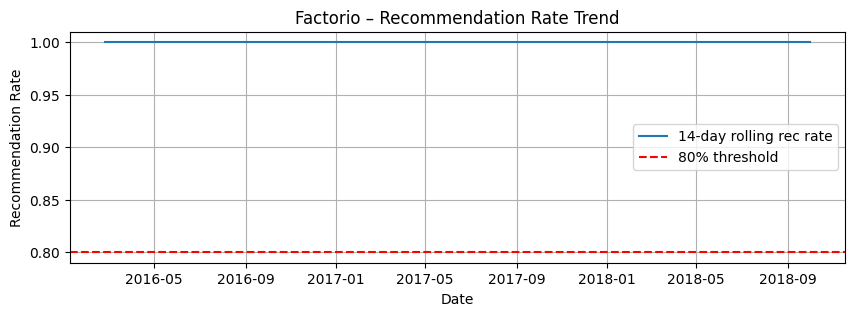

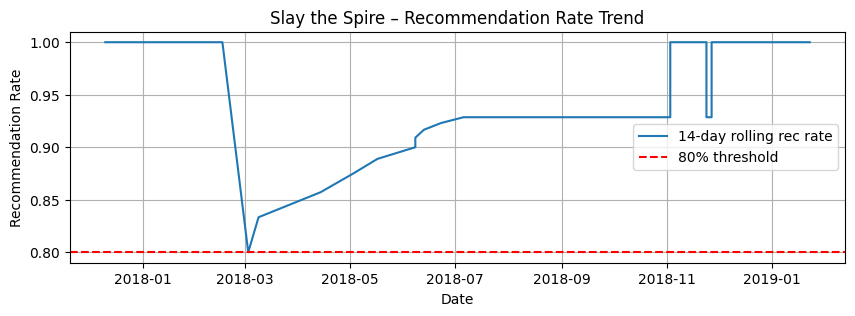

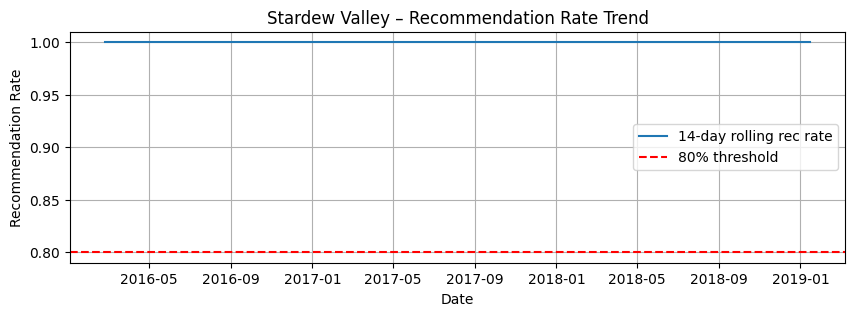

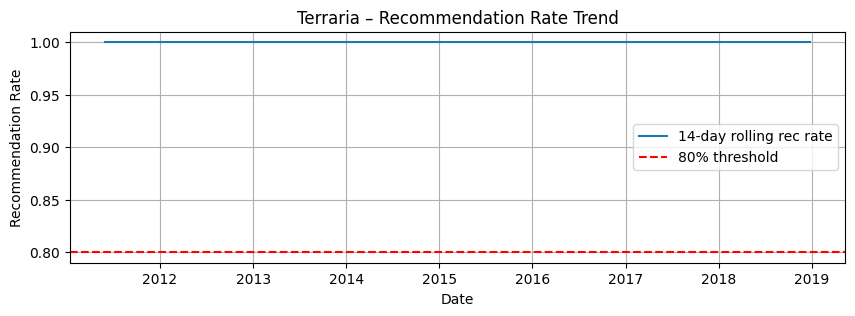

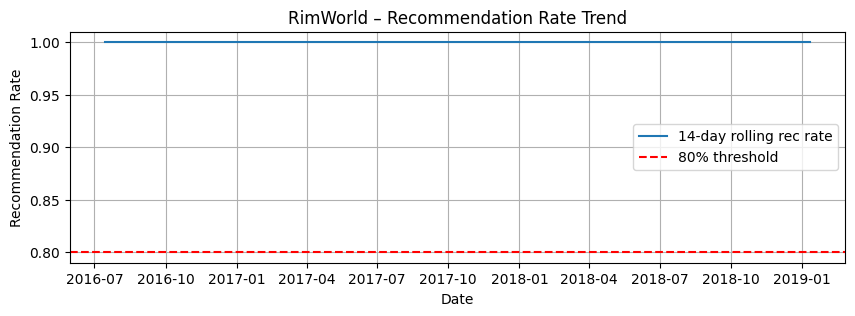

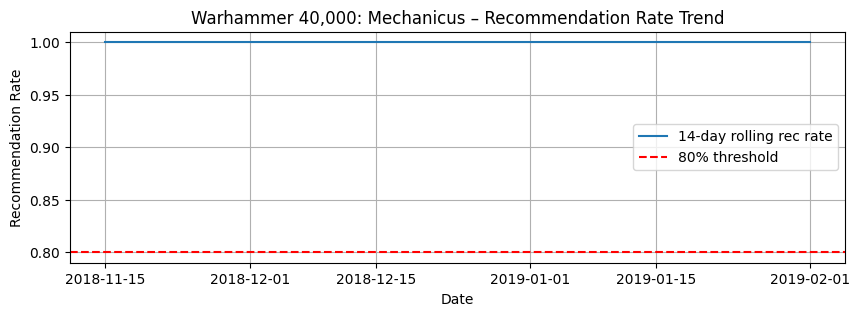

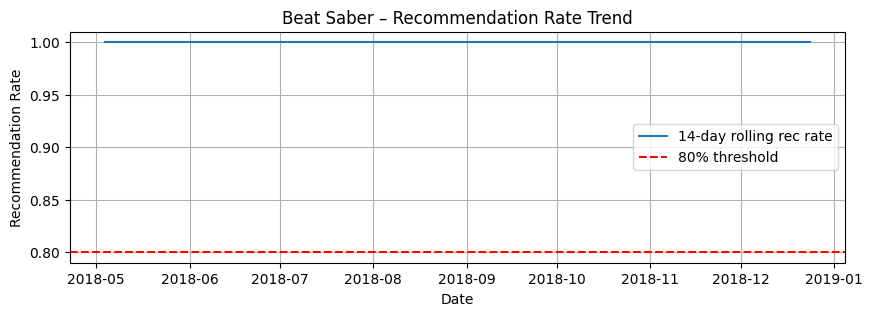

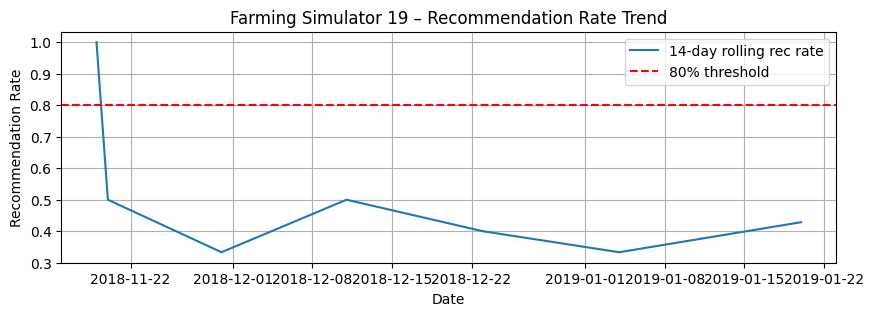

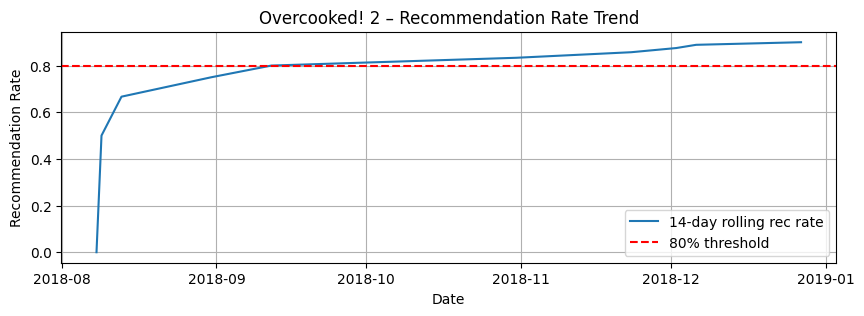

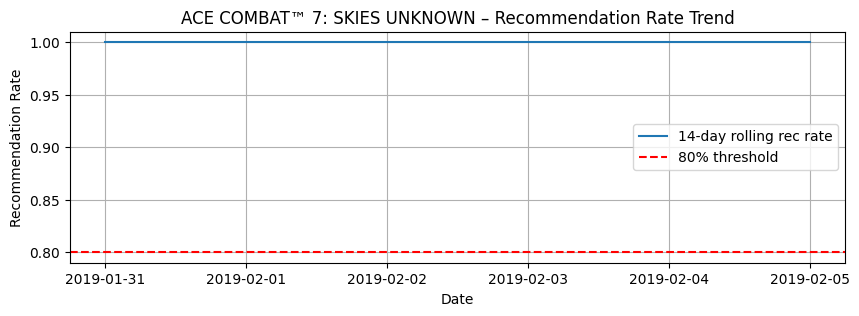

In [15]:
# Plottinh recommendation rate over time
for title in df['title'].unique():
    game = df[df['title'] == title].copy().sort_values('date_posted')
    game['rolling_rec'] = game['is_recommended'].rolling(14, min_periods=1).mean()
    plt.figure(figsize=(10,3))
    plt.plot(game['date_posted'], game['rolling_rec'], label='14‑day rolling rec rate')
    plt.axhline(y=0.8, color='r', linestyle='--', label='80% threshold')
    plt.title(f'{title} – Recommendation Rate Trend')
    plt.ylabel('Recommendation Rate')
    plt.xlabel('Date')
    plt.legend()
    plt.grid(True)
    plt.show()

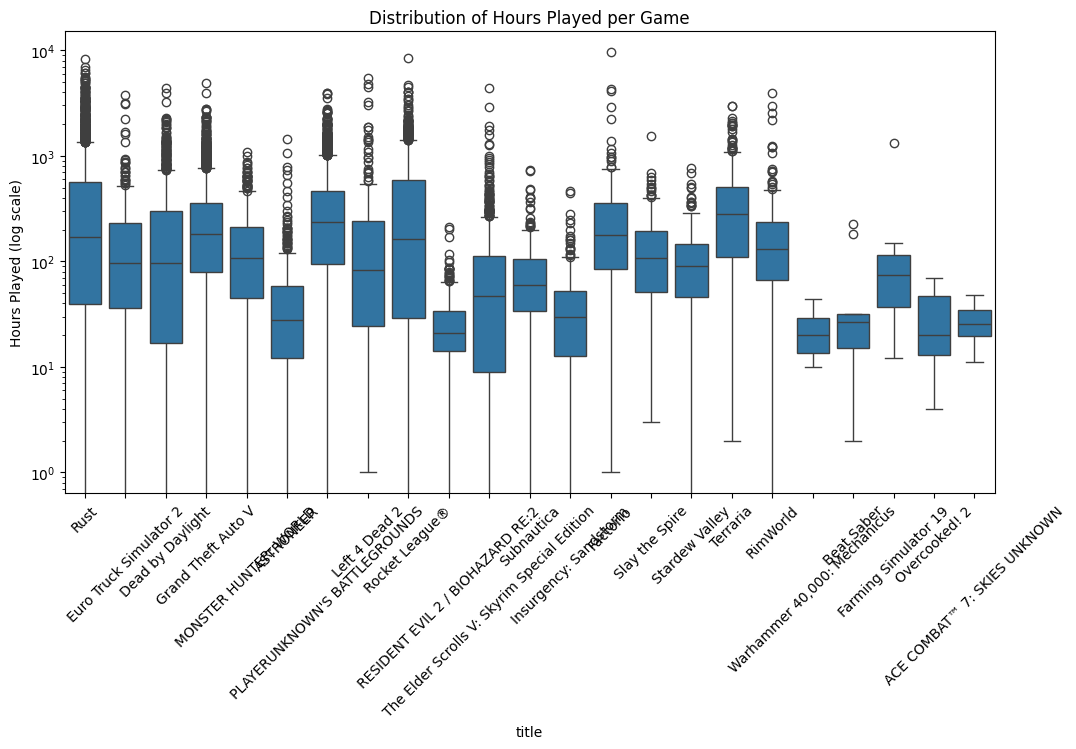

In [16]:
# Boxplot of hours played per game
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='title', y='hour_played')
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel('Hours Played (log scale)')
plt.title('Distribution of Hours Played per Game')
plt.show()

In [17]:
# determining percentage of reviews with over 20 hours and over 50 hours
for title in df['title'].unique():
    sub = df[df['title'] == title]
    pct_20 = (sub['hour_played'] > 20).mean() * 100
    pct_50 = (sub['hour_played'] > 50).mean() * 100
    print(f"{title}: >20h = {pct_20:.1f}% , >50h = {pct_50:.1f}%")

Rust: >20h = 81.7% , >50h = 72.1%
Euro Truck Simulator 2: >20h = 83.9% , >50h = 67.3%
Dead by Daylight: >20h = 72.8% , >50h = 61.8%
Grand Theft Auto V: >20h = 92.1% , >50h = 83.7%
MONSTER HUNTER: WORLD: >20h = 83.5% , >50h = 71.8%
ASTRONEER: >20h = 59.5% , >50h = 29.9%
PLAYERUNKNOWN'S BATTLEGROUNDS: >20h = 91.1% , >50h = 83.8%
Left 4 Dead 2: >20h = 78.7% , >50h = 60.9%
Rocket League®: >20h = 78.6% , >50h = 67.3%
RESIDENT EVIL 2 / BIOHAZARD RE:2: >20h = 52.4% , >50h = 9.3%
The Elder Scrolls V: Skyrim Special Edition: >20h = 64.4% , >50h = 48.2%
Subnautica: >20h = 89.7% , >50h = 63.2%
Insurgency: Sandstorm: >20h = 60.1% , >50h = 27.4%
Factorio: >20h = 93.7% , >50h = 86.1%
Slay the Spire: >20h = 91.3% , >50h = 75.8%
Stardew Valley: >20h = 90.7% , >50h = 71.6%
Terraria: >20h = 91.2% , >50h = 87.0%
RimWorld: >20h = 94.6% , >50h = 80.4%
Warhammer 40,000: Mechanicus: >20h = 42.9% , >50h = 0.0%
Beat Saber: >20h = 70.0% , >50h = 20.0%
Farming Simulator 19: >20h = 85.7% , >50h = 57.1%
Overcooked

### Checking for the effect of early access

In [30]:
# comparing metrics before and after release (early access vs after release)

# flag for post‑full‑release
df['is_post_full_release'] = ~df['is_early_access_review']

# need to know the date when EA ended. Infer it as the first date with is_early_access_review == False
ea_end_date = {}
for title in df['title'].unique():
    sub = df[df['title'] == title].sort_values('date_posted')
    first_non_ea = sub[~sub['is_early_access_review']]['date_posted'].min()
    if pd.notna(first_non_ea):
        ea_end_date[title] = first_non_ea
    else:
        ea_end_date[title] = sub['date_posted'].max() + timedelta(days=1)  # never left EA

df['is_after_full_release'] = df.apply(lambda row: row['date_posted'] >= ea_end_date[row['title']], axis=1)

# Compare metrics
ea_comparison = []
for title in df['title'].unique():
    sub = df[df['title'] == title]
    before = sub[sub['is_early_access_review']]
    after = sub[~sub['is_early_access_review']]
    ea_comparison.append({
        'game': title,
        'ea_rec_rate': before['is_recommended'].mean() if len(before)>0 else np.nan,
        'full_rec_rate': after['is_recommended'].mean() if len(after)>0 else np.nan,
        'ea_median_hours': before['hour_played'].median() if len(before)>0 else np.nan,
        'full_median_hours': after['hour_played'].median() if len(after)>0 else np.nan,
    })
pd.DataFrame(ea_comparison)

,game,ea_rec_rate,full_rec_rate,ea_median_hours,full_median_hours
0,Rust,0.674045,0.629400,152.0,282.0
1,Euro Truck Simulator 2,NaN,1.000000,NaN,96.0
2,Dead by Daylight,NaN,0.630561,NaN,97.0
3,Grand Theft Auto V,NaN,0.632306,NaN,182.0
4,MONSTER HUNTER: WORLD,NaN,0.600775,NaN,107.0
5,ASTRONEER,0.887006,0.555556,28.0,39.0
6,PLAYERUNKNOWN'S BATTLEGROUNDS,0.799532,0.565287,231.0,242.5
7,Left 4 Dead 2,NaN,0.995050,NaN,82.5
8,Rocket League®,NaN,0.605530,NaN,164.5
9,RESIDENT EVIL 2 / BIOHAZARD RE:2,NaN,0.985887,NaN,21.0


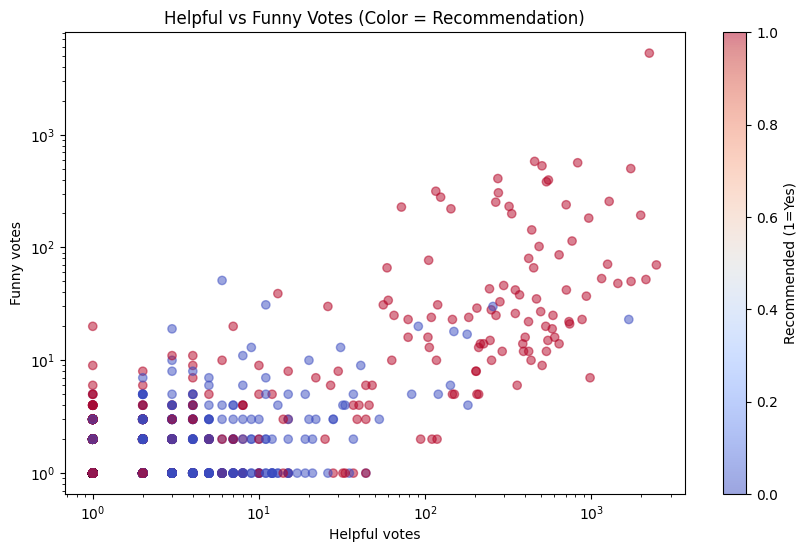

In [20]:
# social validation: votes for helpful and funny

# Scatter plot: helpful vs funny, colored by rec rate
plt.figure(figsize=(10,6))
scatter = plt.scatter(df['helpful'], df['funny'], c=df['is_recommended'], alpha=0.5, cmap='coolwarm')
plt.colorbar(scatter, label='Recommended (1=Yes)')
plt.xlabel('Helpful votes')
plt.ylabel('Funny votes')
plt.title('Helpful vs Funny Votes (Color = Recommendation)')
plt.xscale('log')
plt.yscale('log')
plt.show()

In [21]:
game_stats[['mean_helpful', 'mean_funny']].sort_values('mean_helpful', ascending=False)

,mean_helpful,mean_funny
title,,
ACE COMBAT™ 7: SKIES UNKNOWN,295.25,28.12
Beat Saber,230.00,89.20
Farming Simulator 19,106.86,13.29
Overcooked! 2,63.10,39.60
"Warhammer 40,000: Mechanicus",61.29,1.43
Left 4 Dead 2,24.32,28.92
Subnautica,24.05,1.72
Factorio,21.84,10.13
Stardew Valley,21.75,3.54


In [23]:
# The length of the review may also indicate deeper analysis
df['review_len'] = df['review'].astype(str).apply(len)

# Average length per game (only recommended vs not)
length_stats = df.groupby(['title', 'is_recommended'])['review_len'].mean().unstack()
length_stats.columns = ['len_not_rec', 'len_rec']
length_stats

,len_not_rec,len_rec
title,,
ACE COMBAT™ 7: SKIES UNKNOWN,NaN,944.750000
ASTRONEER,575.950000,319.080645
Beat Saber,NaN,637.300000
Dead by Daylight,365.424084,222.150307
Euro Truck Simulator 2,NaN,207.433333
Factorio,NaN,301.721519
Farming Simulator 19,1725.750000,1096.000000
Grand Theft Auto V,236.178974,149.493450
Insurgency: Sandstorm,621.916667,251.102041


### Summary of the risk signals

In [25]:
# Compute additional signals
signals = game_stats.copy()
signals['rec_rate_trend'] = None
signals['week_over_week_growth'] = None  # placeholder

# Simple trend: difference in rec rate between first 30% and last 30% of reviews
trend_list = []
for title in df['title'].unique():
    sub = df[df['title'] == title].sort_values('date_posted')
    n = len(sub)
    first = sub.head(max(1, int(0.3*n)))['is_recommended'].mean()
    last = sub.tail(max(1, int(0.3*n)))['is_recommended'].mean()
    trend_list.append(last - first)
signals['rec_trend'] = trend_list

signals['risk_category'] = 'Medium'
signals.loc[(signals['rec_rate'] > 0.8) & (signals['median_hours'] > 20) & (signals['rec_trend'] > -0.05), 'risk_category'] = 'Low Risk / Long-term'
signals.loc[(signals['n_reviews'] > 500) & (signals['median_hours'] < 10) & (signals['rec_trend'] < -0.1), 'risk_category'] = 'High Risk / Short-term Buzz'

signals[['n_reviews', 'rec_rate', 'median_hours', 'rec_trend', 'risk_category']].sort_values('rec_rate', ascending=False)

,n_reviews,rec_rate,median_hours,rec_trend,risk_category
title,,,,,
ACE COMBAT™ 7: SKIES UNKNOWN,8,1.00,25.5,-0.110626,Medium
Beat Saber,10,1.00,26.5,0.087097,Low Risk / Long-term
Euro Truck Simulator 2,330,1.00,96.0,0.215517,Low Risk / Long-term
Factorio,158,1.00,176.5,0.029070,Low Risk / Long-term
"Warhammer 40,000: Mechanicus",7,1.00,20.0,0.000000,Medium
RimWorld,184,1.00,130.5,0.000000,Low Risk / Long-term
Left 4 Dead 2,202,1.00,82.5,0.040541,Low Risk / Long-term
Subnautica,204,1.00,60.0,0.000000,Low Risk / Long-term
Terraria,239,1.00,283.0,0.000000,Low Risk / Long-term


In [27]:
# Exporting the table for the modelling part
signals.to_csv('/content/drive/MyDrive/game_acquisition_signals.csv')


In [29]:
# saving cleaned dataset for the modelling part
df_clean = df.drop(columns=['review'])
df_clean.to_csv('/content/drive/MyDrive/game_reviews_cleaned.csv', index=False)